# DECIFRA SLURM Error Analysis
This notebook scans local SLURM `_error/` logs for `CUDA error: an illegal memory access was encountered`, parses the array indices from the filenames, and reverse-maps them to the exact configuration `.yaml` files originally submitted by the Batch scripts.

In [2]:
import os
import glob
import re
from collections import defaultdict

# Define config mappings mirroring the bash scripts modulo logic
mappings = {
    "meanGRU": [
        "all_shared.yaml",
        "all_independent.yaml",
        "shared_features_independent_dynamics.yaml",
        "independent_features_shared_dynamics.yaml"
    ],
    "exp": [ # 03_batch_pretraining_ukb_exp.sh (meanGRU large/small mix)
        "all_shared.yaml",
        "all_independent.yaml",
        "shared_features_independent_dynamics.yaml",
        "independent_features_shared_dynamics.yaml",
        "all_shared_large.yaml",
        "independent_features_shared_dynamics_large.yaml"
    ],
    "meanLSTM": [
        "all_shared.yaml",
        "all_independent.yaml",
        "shared_features_independent_dynamics.yaml",
        "independent_features_shared_dynamics.yaml"
    ],
    "VAR": [
        "lag_5_full.yaml",
        "lag_5_single.yaml",
        "lag_5_multi.yaml",
        "lag_20_full.yaml",
        "lag_20_single.yaml",
        "lag_20_multi.yaml"
    ]
}

error_dir = "../_error/"
if not os.path.exists(error_dir):
    error_dir = "./_error/" # Try local dir if running from root

error_logs = glob.glob(os.path.join(error_dir, "*.err"))
print(f"Found {len(error_logs)} total .err files.")

Found 171 total .err files.


In [ ]:
target_error = "an illegal memory access was encountered"

# Stats trackers
total_jobs = defaultdict(lambda: defaultdict(int))
failed_jobs = defaultdict(lambda: defaultdict(int))

# Regex to extract job prefix and array index. E.g. error_meanlstm12345_12.err -> ('meanGRU', 12)
filename_pattern = re.compile(r"error_([a-zA-Z]+)\d+_(\d+)\.err")

for log_file in error_logs:
    basename = os.path.basename(log_file)
    match = filename_pattern.search(basename)
    if not match:
        continue
        
    experiment_type = match.group(1)
    array_idx = int(match.group(2))
    
    # Match to config
    if experiment_type in mappings:
        configs = mappings[experiment_type]
        config_idx = array_idx % len(configs)
        config_name = configs[config_idx]
        
        total_jobs[experiment_type][config_name] += 1
        
        # Check for failure
        try:
            with open(log_file, 'r') as f:
                if target_error in f.read():
                    failed_jobs[experiment_type][config_name] += 1
        except:
            pass


In [4]:
import pandas as pd

print("========== CUDA MEMORY CRASH STATISTICS ==========")

records = []
for exp_type, config_counts in total_jobs.items():
    for config_name, total in config_counts.items():
        fails = failed_jobs[exp_type].get(config_name, 0)
        rate = (fails / total) * 100 if total > 0 else 0
        records.append({
            "Experiment": exp_type, 
            "Configuration": config_name,
            "Total Scanned": total,
            "Memory Crashes": fails,
            "Failure Rate (%)": f"{rate:.1f}%"
        })

df = pd.DataFrame(records)
if len(df) > 0:
    display(df.sort_values(["Experiment", "Memory Crashes"], ascending=[True, False]))
else:
    print("No matching standard DECIFRA logs found or scanned.")

========== CUDA MEMORY CRASH STATISTICS ==========


,Experiment,Configuration,Total Scanned,Memory Crashes,Failure Rate (%)
10,VAR,lag_5_full.yaml,10,0,0.0%
11,VAR,lag_5_single.yaml,10,0,0.0%
12,VAR,lag_20_full.yaml,10,0,0.0%
13,VAR,lag_20_multi.yaml,10,0,0.0%
14,VAR,lag_20_single.yaml,10,0,0.0%
15,VAR,lag_5_multi.yaml,10,0,0.0%
4,exp,all_shared_large.yaml,5,3,60.0%
6,exp,independent_features_shared_dynamics.yaml,5,2,40.0%
7,exp,independent_features_shared_dynamics_large.yaml,4,2,50.0%
9,exp,all_shared.yaml,5,2,40.0%


# Training Curves
We pull `train_logs.csv` from the experiment outputs and plot the validation loss across epochs.
We will separate the plots into two groups: 
1. `ukb` default dataset (Script 01 runs, orchestrated by 02/04/05)
2. `ukb_exp` dataset (Script 03 runs)

In [30]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# We will collect all logs into a single dataframe
all_data = []
log_base_dir = "../assets/logs/"
if not os.path.exists(log_base_dir):
    log_base_dir = "./assets/logs/"

for exp_folder in sorted(os.listdir(log_base_dir)):
    exp_path = os.path.join(log_base_dir, exp_folder)
    if not os.path.isdir(exp_path) or not exp_folder.startswith("1_pretrain-"):
        continue
        
    parts = exp_folder.split("-")
    if len(parts) >= 3:
        dataset = parts[1]
        model = parts[2]
        config = "-".join(parts[3:]) if len(parts) > 3 else "default"
    else:
        continue
        
    dataset_group = "ukb_exp" if dataset == "ukb_exp" else "ukb" if dataset == "ukb" else "dummy"
    dataset_group = dataset
    
    for idx_folder in os.listdir(exp_path):
        idx_path = os.path.join(exp_path, idx_folder)
        if not os.path.isdir(idx_path):
            continue
            
        csv_path = os.path.join(idx_path, "train_logs.csv")
        if os.path.exists(csv_path):
            try:
                df = pd.read_csv(csv_path)
                df["dataset"] = dataset_group
                df["experiment"] = f"{model}_{config}"
                df["run_idx"] = idx_folder
                all_data.append(df)
            except Exception as e:
                pass

if all_data:
    full_df = pd.concat(all_data, ignore_index=True)
    print(f"Loaded {len(full_df)} total epoch records across {full_df['experiment'].nunique()} configurations.")
else:
    print("No training logs found.")
    full_df = pd.DataFrame()

Loaded 84725 total epoch records across 28 configurations.


In [31]:
def plot_df(df):
    fig, ax = plt.subplots(figsize=(10, 7))
    sns.lineplot(data=df, x="epoch", y="val_loss", hue="experiment", errorbar="sd")
    ax.set_ylim(0.35, 0.5)
    plt.title(f"Validation Loss Curves")
    plt.ylabel("Validation Loss")
    plt.xlabel("Epoch")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

### VAR
lag_20_full >
lag_20_multi

VAR Configurations Ranked by Average Best Validation Loss:


,experiment,avg_best_val_loss,std_best_val_loss,total_runs_completed
0,VAR_lag_20_full,0.422791,0.000061,10
3,VAR_lag_5_full,0.425360,0.000168,10
1,VAR_lag_20_multi,0.458470,0.001494,10
2,VAR_lag_20_single,0.467687,0.006032,10
5,VAR_lag_5_single,0.473875,0.018091,10
4,VAR_lag_5_multi,0.474468,0.005008,10


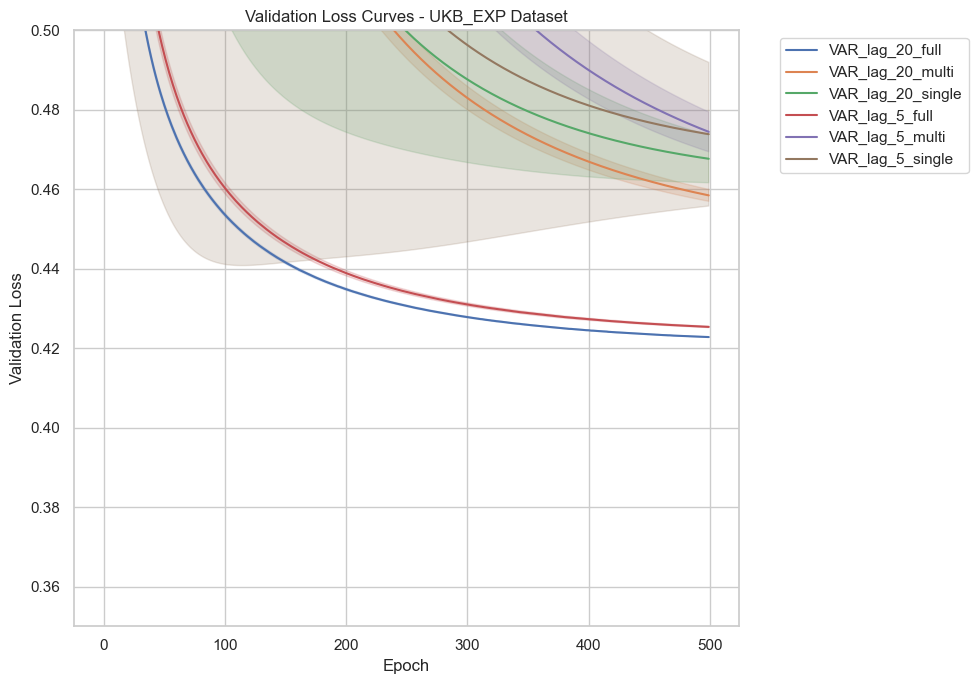

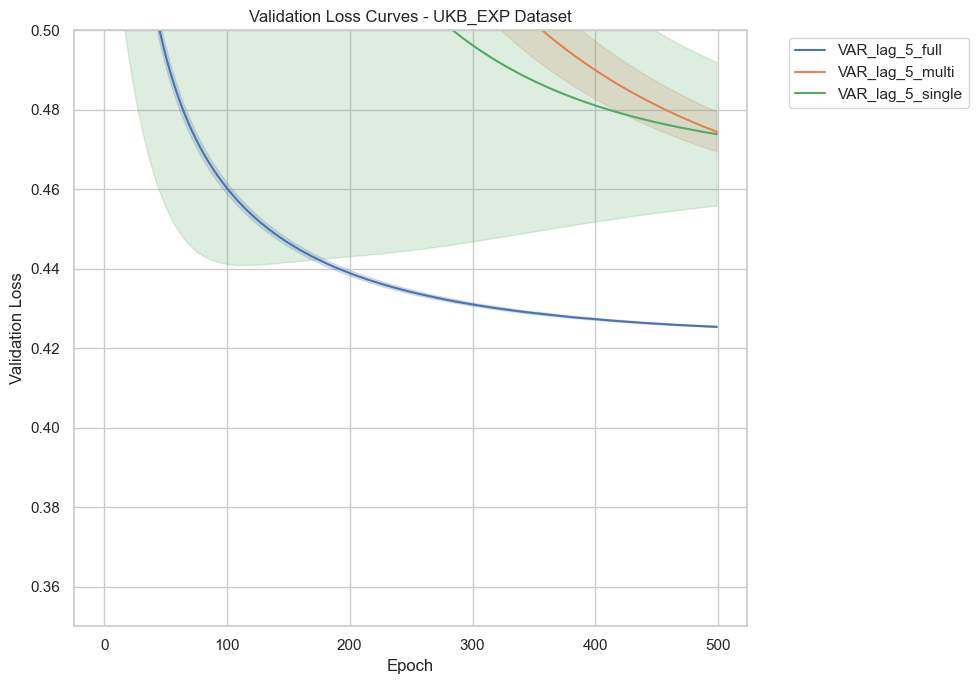

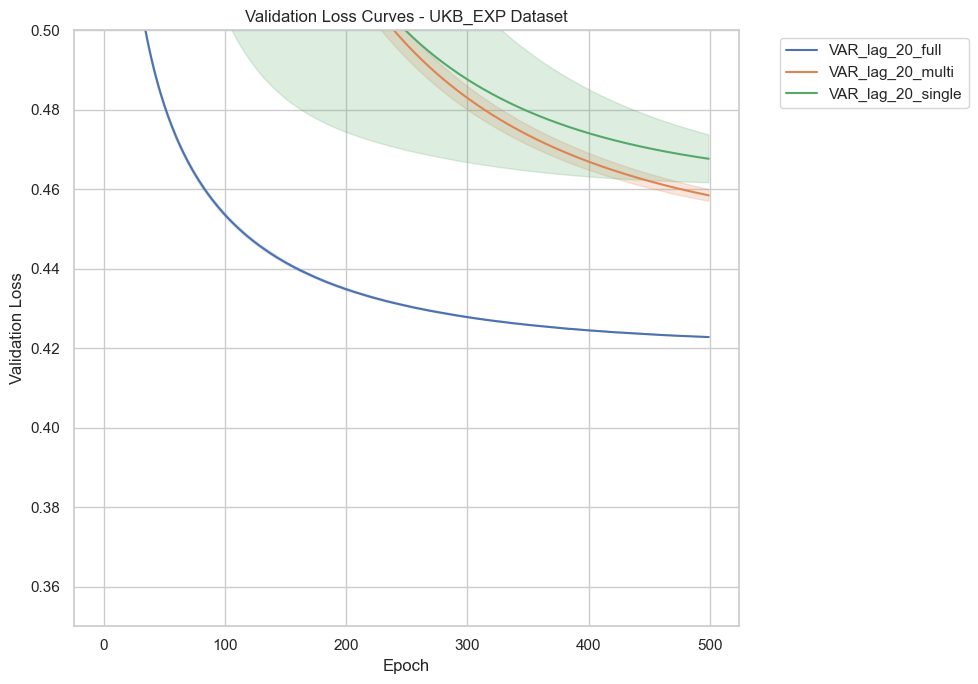

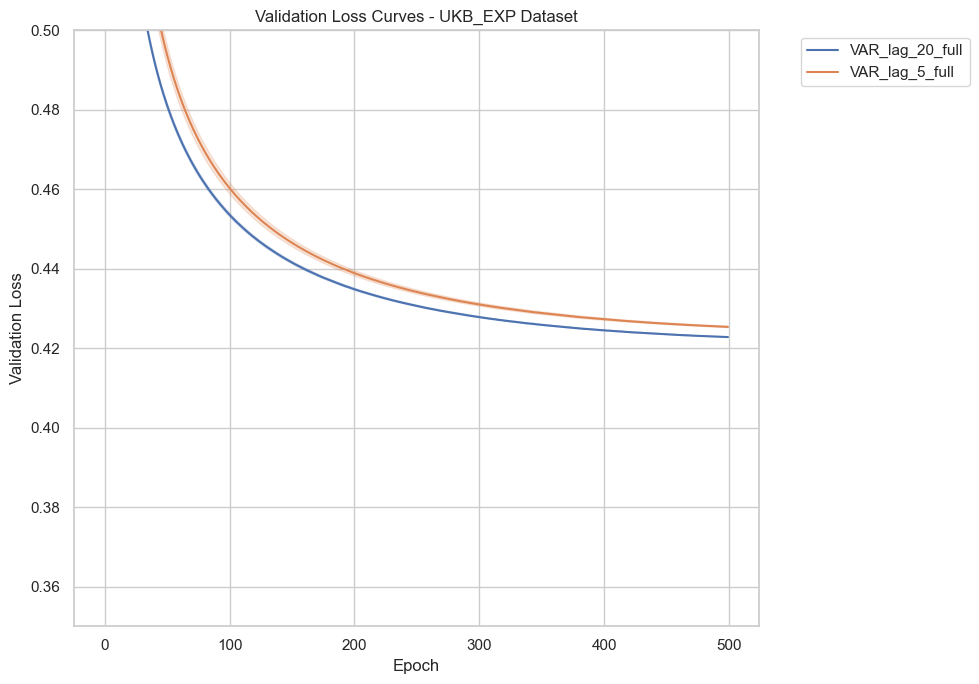

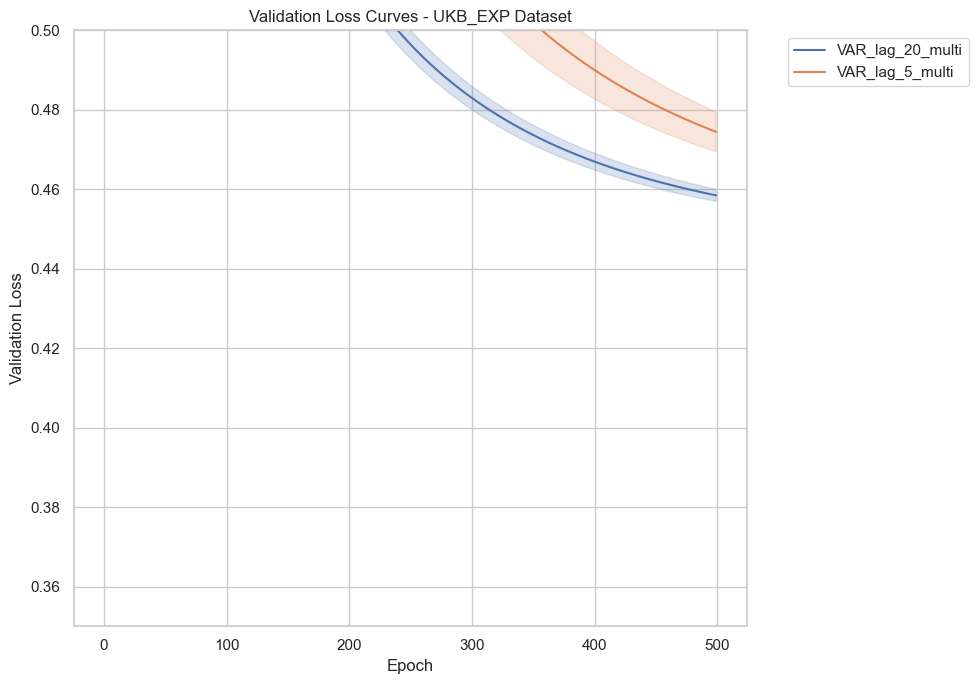

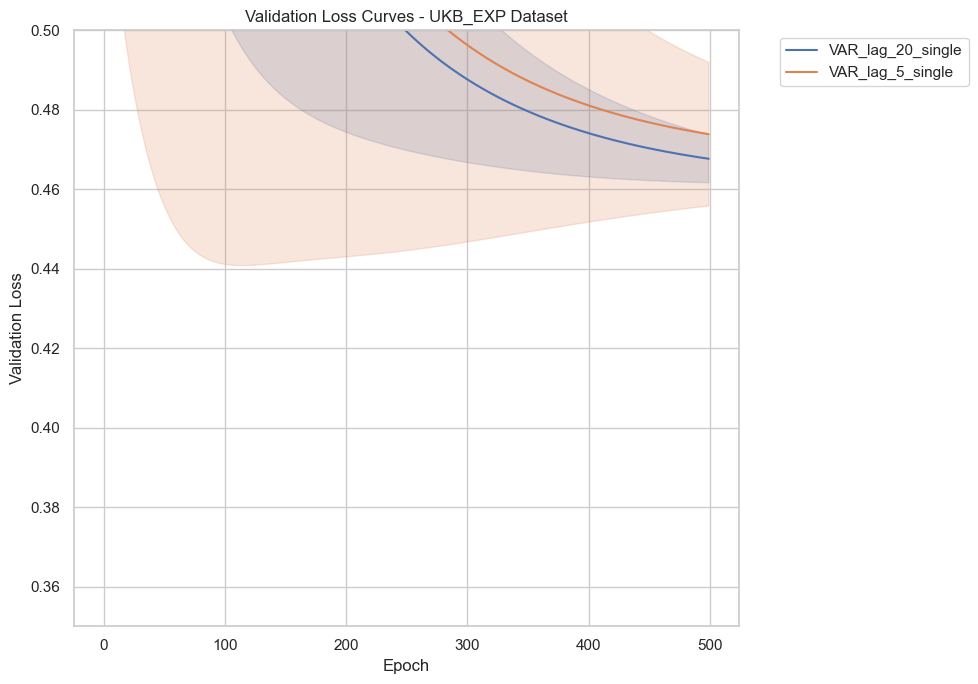

In [62]:
# get best models
subset_df = full_df[full_df["model"] == 'VAR']
var_df = subset_df[subset_df["dataset"] == "ukb"]

# 1. Get the absolute best validation loss for EVERY independent run
best_per_run = (
    var_df.groupby(["experiment", "run_idx"])["val_loss"]
    .min()
    .reset_index(name="best_loss_for_run")
)

# 2. Average those best losses across all runs for a given configuration
average_best_configs = (
    best_per_run.groupby("experiment")
    .agg(
        avg_best_val_loss=("best_loss_for_run", "mean"),
        std_best_val_loss=("best_loss_for_run", "std"),      # Shows stability across runs
        total_runs_completed=("best_loss_for_run", "count")  # Verifies how many runs succeeded
    )
    .reset_index()
    .sort_values(by="avg_best_val_loss", ascending=True)     # Rank lowest (best) to highest
)

print("VAR Configurations Ranked by Average Best Validation Loss:")
display(average_best_configs)


# plot VAR
plot_df(var_df)

for exp in ["5", "20"]:
    # get rows with experiment containing exp
    ssubset_df = var_df[var_df["experiment"].str.contains(exp)]
    plot_df(ssubset_df)

subset_df = full_df[full_df["model"] == 'VAR']
for exp in ["full", "multi", "single"]:
    # get rows with experiment containing exp
    ssubset_df = var_df[var_df["experiment"].str.contains(exp)]
    plot_df(ssubset_df)

### meanLSTM
shared_features_independent_dynamics >
all_independent

meanlstm Configurations Ranked by Average Best Validation Loss on ukb_exp:


,experiment,avg_best_val_loss,std_best_val_loss,total_runs_completed
0,meanLSTM_all_independent,0.429769,0.000561,10
3,meanLSTM_shared_features_independent_dynamics,0.429944,0.000681,10
1,meanLSTM_all_shared,0.432449,0.000826,10
2,meanLSTM_independent_features_shared_dynamics,0.444223,0.001569,10


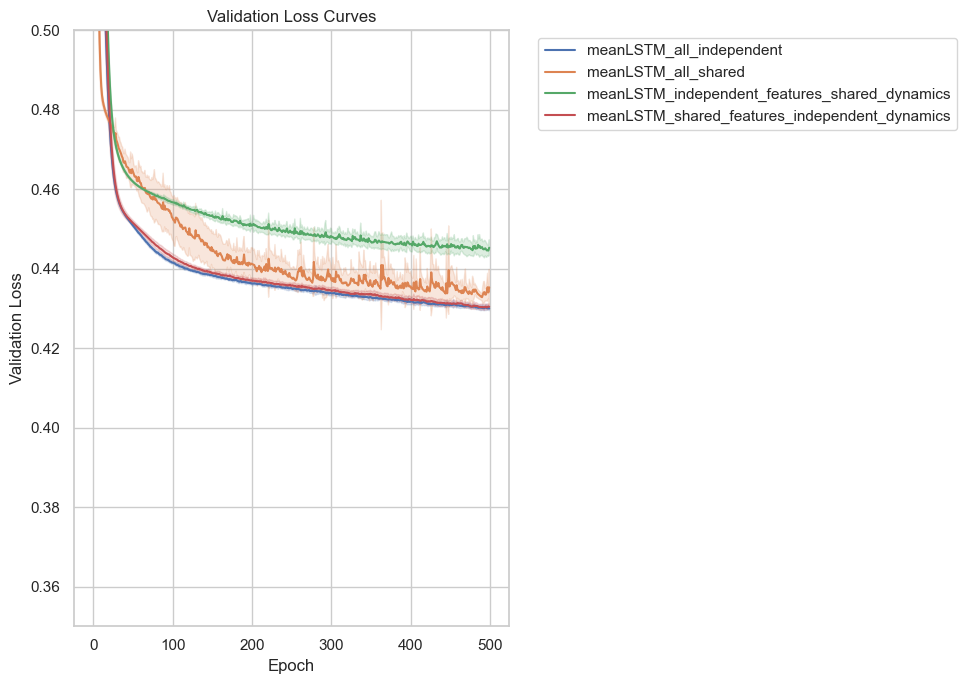

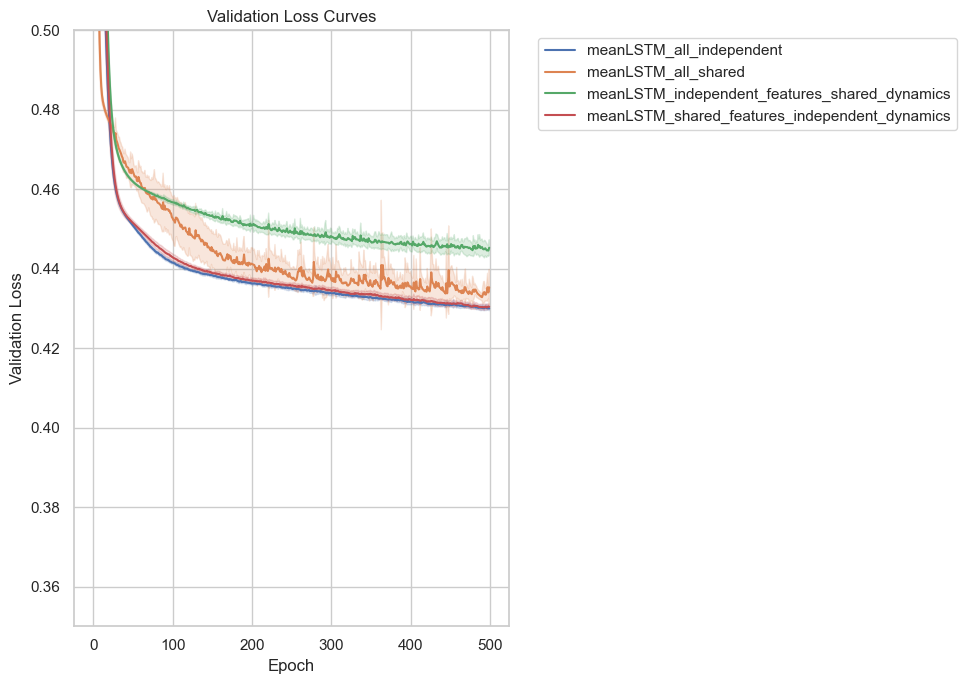

In [ ]:
# Filter for meanlstm models on ukb_exp dataset
lstm_df = full_df[(full_df["model"] == "meanLSTM") & (full_df["dataset"] == "ukb")].copy()

# 1. Get the absolute best validation loss for EVERY independent run
best_per_run_lstm = (
    lstm_df.groupby(["experiment", "run_idx"])["val_loss"]
    .min()
    .reset_index(name="best_loss_for_run")
)

# 2. Average those best losses across all runs for a given configuration
average_best_configs_lstm = (
    best_per_run_lstm.groupby("experiment")
    .agg(
        avg_best_val_loss=("best_loss_for_run", "mean"),
        std_best_val_loss=("best_loss_for_run", "std"),
        total_runs_completed=("best_loss_for_run", "count")
    )
    .reset_index()
    .sort_values(by="avg_best_val_loss", ascending=True)
)

print("meanlstm Configurations Ranked by Average Best Validation Loss on ukb_exp:")
display(average_best_configs_lstm)

# plot the curves 

# Compare ALL meanlstm models on ukb
if not lstm_df.empty:
    plot_df(lstm_df)

small_df = lstm_df[~lstm_df["experiment"].str.contains("_large")]
plot_df(small_df)
# large_df = lstm_df[lstm_df["experiment"].str.contains("_large")]
# plot_df(large_df)

# # Separately compare each small + large config pair
# base_configs = [
#     "all_shared",
#     "all_independent",
#     "shared_features_independent_dynamics",
#     "independent_features_shared_dynamics"
# ]
# for base in base_configs:
#     # We want exact matches for 'meanlstm_{base}' and 'meanlstm_{base}_large'
#     configs_to_match = [f"meanLSTM_{base}", f"meanLSTM_{base}_large"]
#     pair_df = lstm_df[lstm_df["experiment"].isin(configs_to_match)]
#     plot_df(pair_df)

### meanGRU
shared_features_independent_dynamics >
all_independent

Analyzing the performance of `meanGRU` configs (small vs large) on the `ukb_exp` dataset.

meanGRU Configurations Ranked by Average Best Validation Loss on ukb_exp:


,experiment,avg_best_val_loss,std_best_val_loss,total_runs_completed
3,meanGRU_shared_features_independent_dynamics,0.427480,0.000364,10
0,meanGRU_all_independent,0.427509,0.000192,10
1,meanGRU_all_shared,0.432113,NaN,1
2,meanGRU_independent_features_shared_dynamics,0.436952,NaN,1


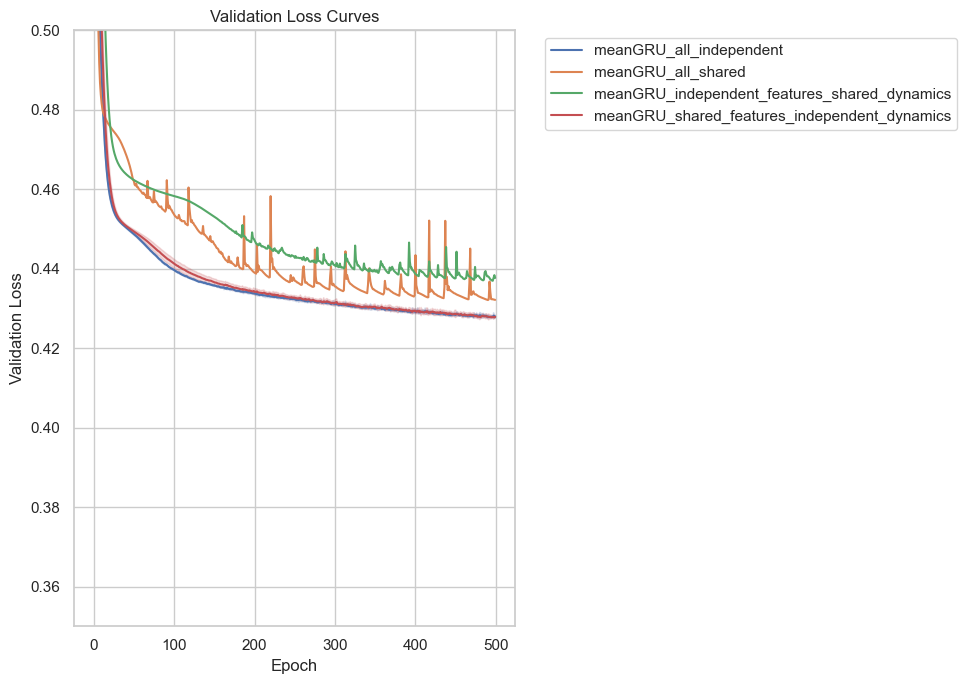

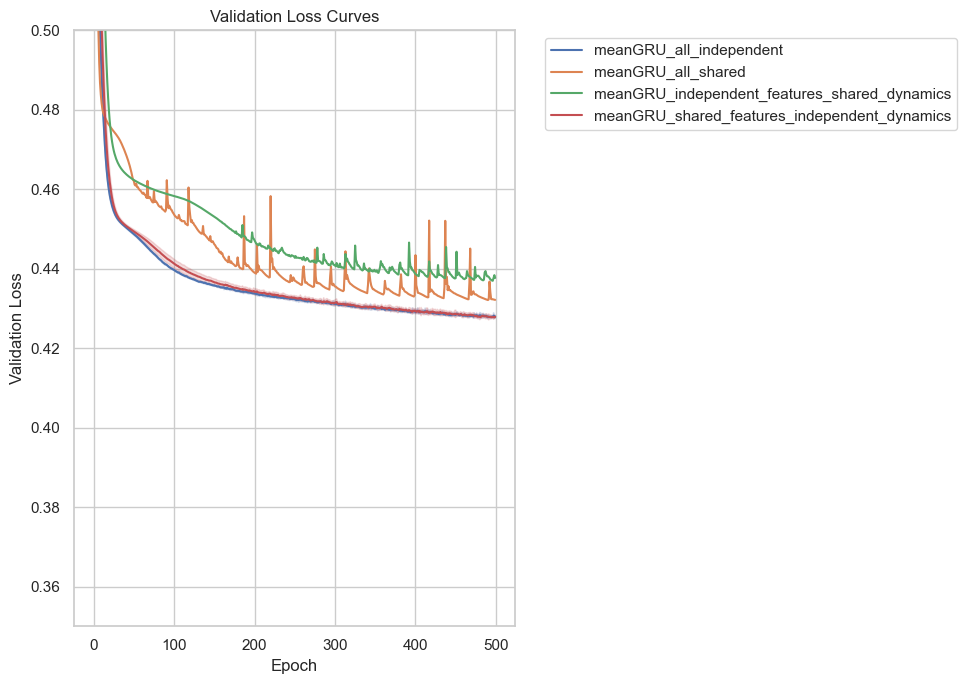

In [68]:
# Filter for meanGRU models on ukb_exp dataset
gru_df = full_df[(full_df["model"] == "meanGRU") & (full_df["dataset"] == "ukb")].copy()

# 1. Get the absolute best validation loss for EVERY independent run
best_per_run_gru = (
    gru_df.groupby(["experiment", "run_idx"])["val_loss"]
    .min()
    .reset_index(name="best_loss_for_run")
)

# 2. Average those best losses across all runs for a given configuration
average_best_configs_gru = (
    best_per_run_gru.groupby("experiment")
    .agg(
        avg_best_val_loss=("best_loss_for_run", "mean"),
        std_best_val_loss=("best_loss_for_run", "std"),
        total_runs_completed=("best_loss_for_run", "count")
    )
    .reset_index()
    .sort_values(by="avg_best_val_loss", ascending=True)
)

print("meanGRU Configurations Ranked by Average Best Validation Loss on ukb_exp:")
display(average_best_configs_gru)

# plot the curves 

# Compare ALL meanGRU models on ukb
if not gru_df.empty:
    plot_df(gru_df)

small_df = gru_df[~gru_df["experiment"].str.contains("_large")]
plot_df(small_df)
# large_df = gru_df[gru_df["experiment"].str.contains("_large")]
# plot_df(large_df)

# # Separately compare each small + large config pair
# base_configs = [
#     "all_shared",
#     "all_independent",
#     "shared_features_independent_dynamics",
#     "independent_features_shared_dynamics"
# ]
# for base in base_configs:
#     # We want exact matches for 'meanGRU_{base}' and 'meanGRU_{base}_large'
#     configs_to_match = [f"meanGRU_{base}", f"meanGRU_{base}_large"]
#     pair_df = gru_df[gru_df["experiment"].isin(configs_to_match)]
#     plot_df(pair_df)

### meanGRU on ukb_exp
independent_features_shared_dynamics_large is best large

all_shared

meanGRU Configurations Ranked by Average Best Validation Loss on ukb_exp:


,experiment,avg_best_val_loss,std_best_val_loss,total_runs_completed
5,meanGRU_independent_features_shared_dynamics_l...,0.385084,NaN,1
3,meanGRU_all_shared_large,0.389972,NaN,1
7,meanGRU_shared_features_independent_dynamics_l...,0.395872,0.000710,3
1,meanGRU_all_independent_large,0.399378,0.001620,3
2,meanGRU_all_shared,0.406741,NaN,1
4,meanGRU_independent_features_shared_dynamics,0.411083,0.003279,2
0,meanGRU_all_independent,0.418272,0.005046,4
6,meanGRU_shared_features_independent_dynamics,0.418636,0.001998,4


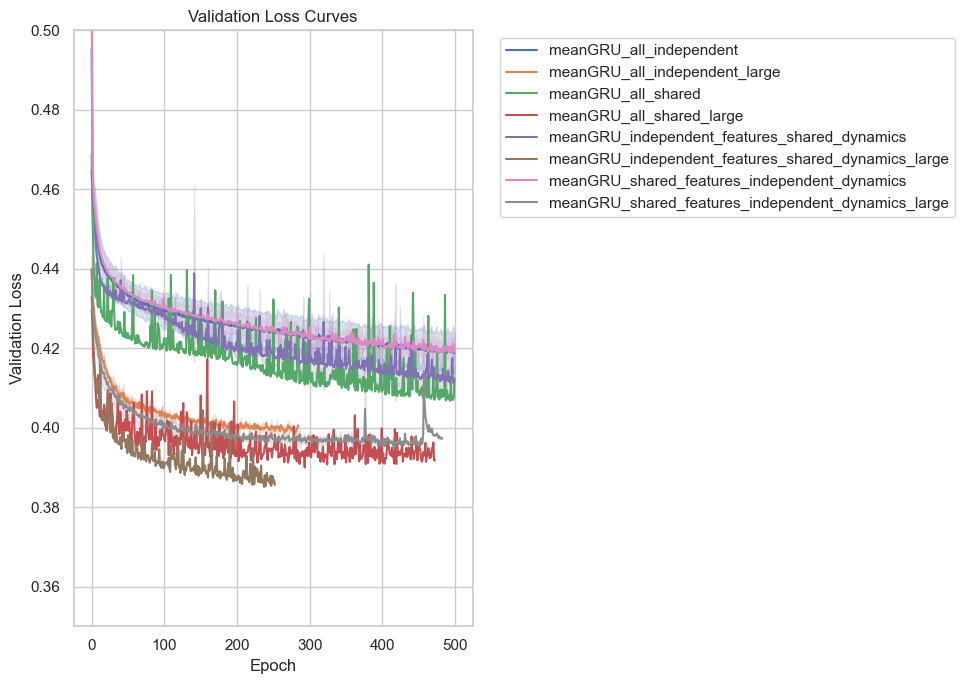

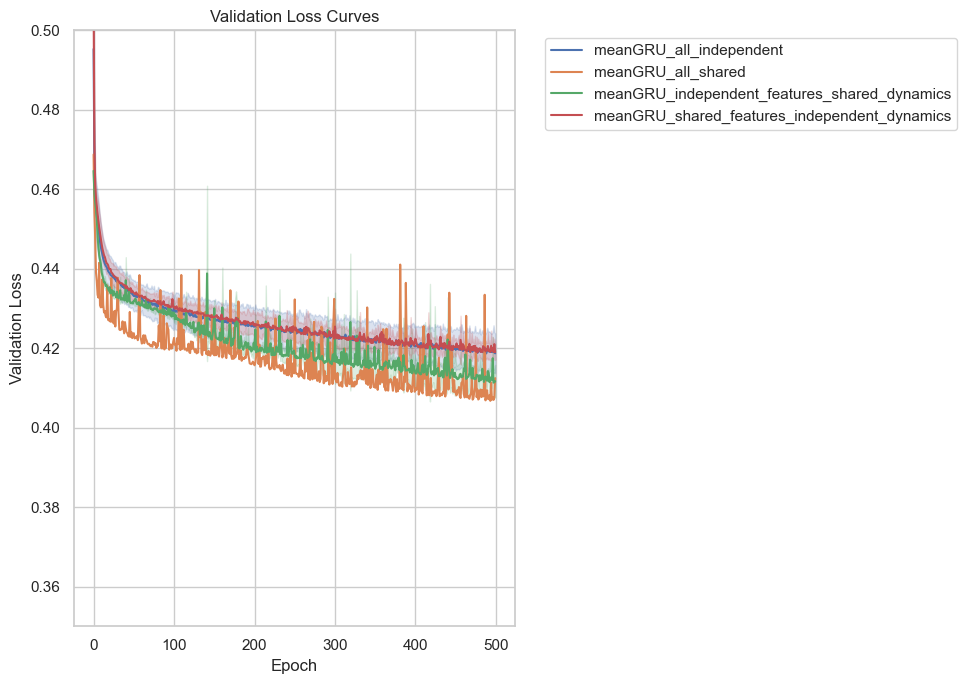

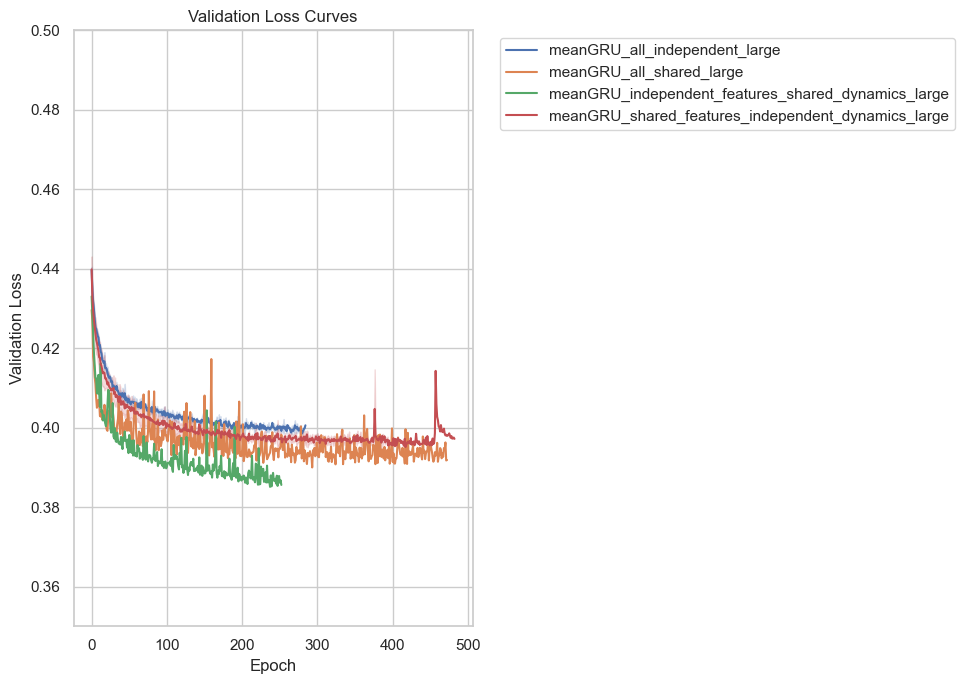

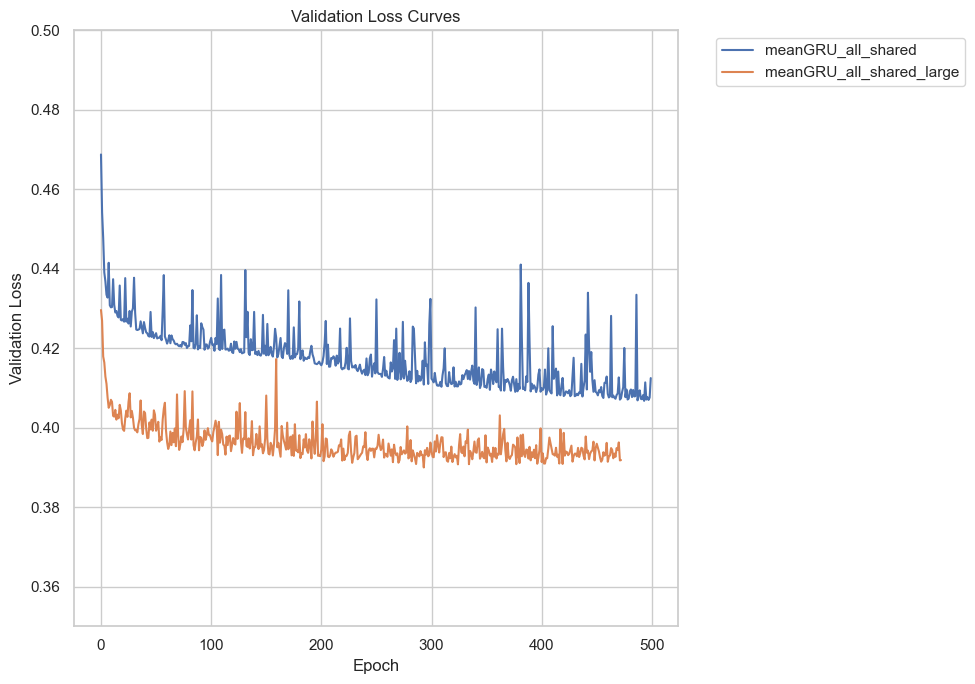

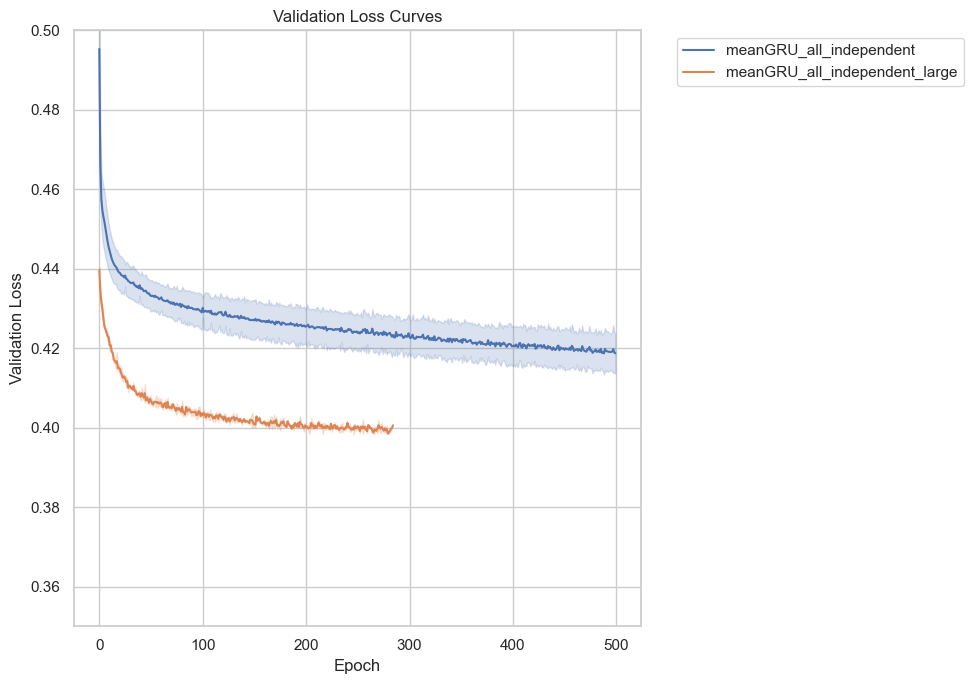

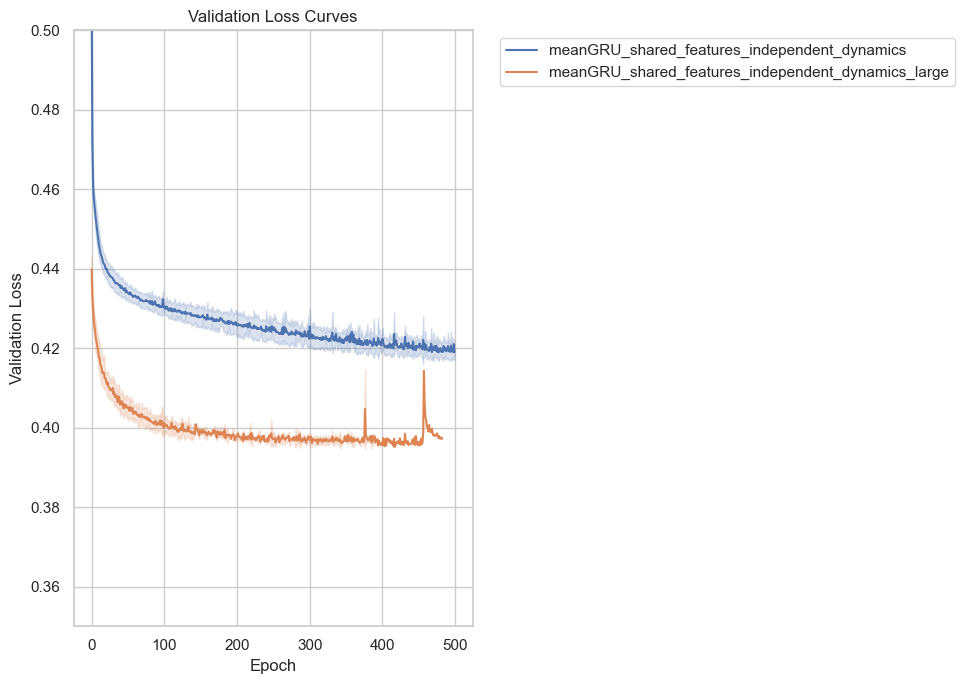

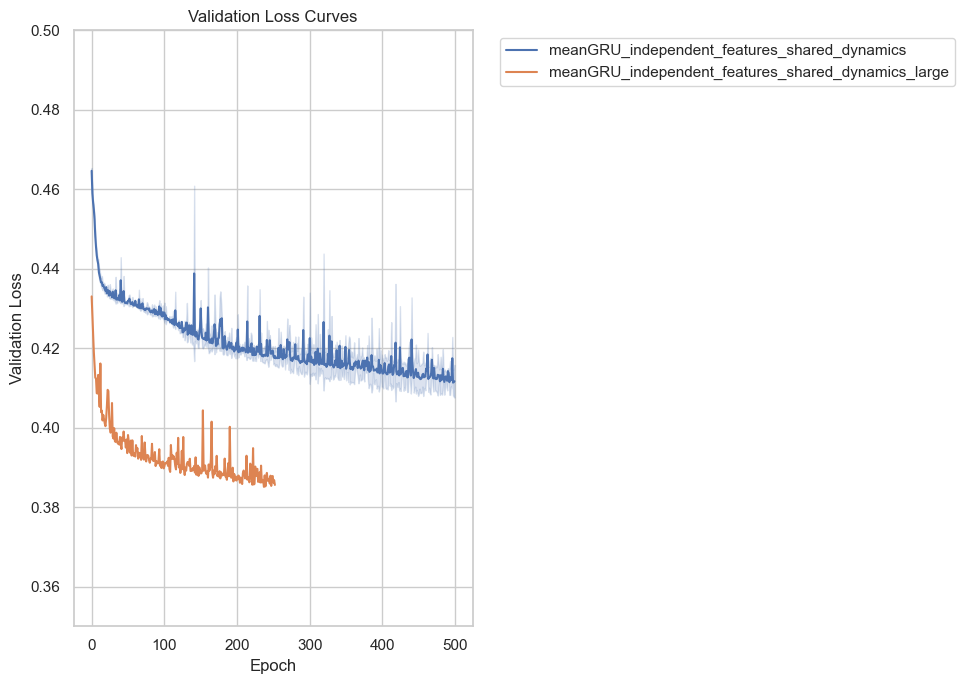

In [70]:
# Filter for meanGRU models on ukb_exp dataset
gru_df = full_df[(full_df["model"] == "meanGRU") & (full_df["dataset"] == "ukb_exp")].copy()

# 1. Get the absolute best validation loss for EVERY independent run
best_per_run_gru = (
    gru_df.groupby(["experiment", "run_idx"])["val_loss"]
    .min()
    .reset_index(name="best_loss_for_run")
)

# 2. Average those best losses across all runs for a given configuration
average_best_configs_gru = (
    best_per_run_gru.groupby("experiment")
    .agg(
        avg_best_val_loss=("best_loss_for_run", "mean"),
        std_best_val_loss=("best_loss_for_run", "std"),
        total_runs_completed=("best_loss_for_run", "count")
    )
    .reset_index()
    .sort_values(by="avg_best_val_loss", ascending=True)
)

print("meanGRU Configurations Ranked by Average Best Validation Loss on ukb_exp:")
display(average_best_configs_gru)

# plot the curves 

# Compare ALL meanGRU models on ukb
if not gru_df.empty:
    plot_df(gru_df)

small_df = gru_df[~gru_df["experiment"].str.contains("_large")]
plot_df(small_df)
large_df = gru_df[gru_df["experiment"].str.contains("_large")]
plot_df(large_df)

# Separately compare each small + large config pair
base_configs = [
    "all_shared",
    "all_independent",
    "shared_features_independent_dynamics",
    "independent_features_shared_dynamics"
]
for base in base_configs:
    # We want exact matches for 'meanGRU_{base}' and 'meanGRU_{base}_large'
    configs_to_match = [f"meanGRU_{base}", f"meanGRU_{base}_large"]
    pair_df = gru_df[gru_df["experiment"].isin(configs_to_match)]
    plot_df(pair_df)

### Top Models Comparison
Comparing the absolute best configurations natively across the `VAR`, `meanLSTM`, and `meanGRU` models on `ukb`.

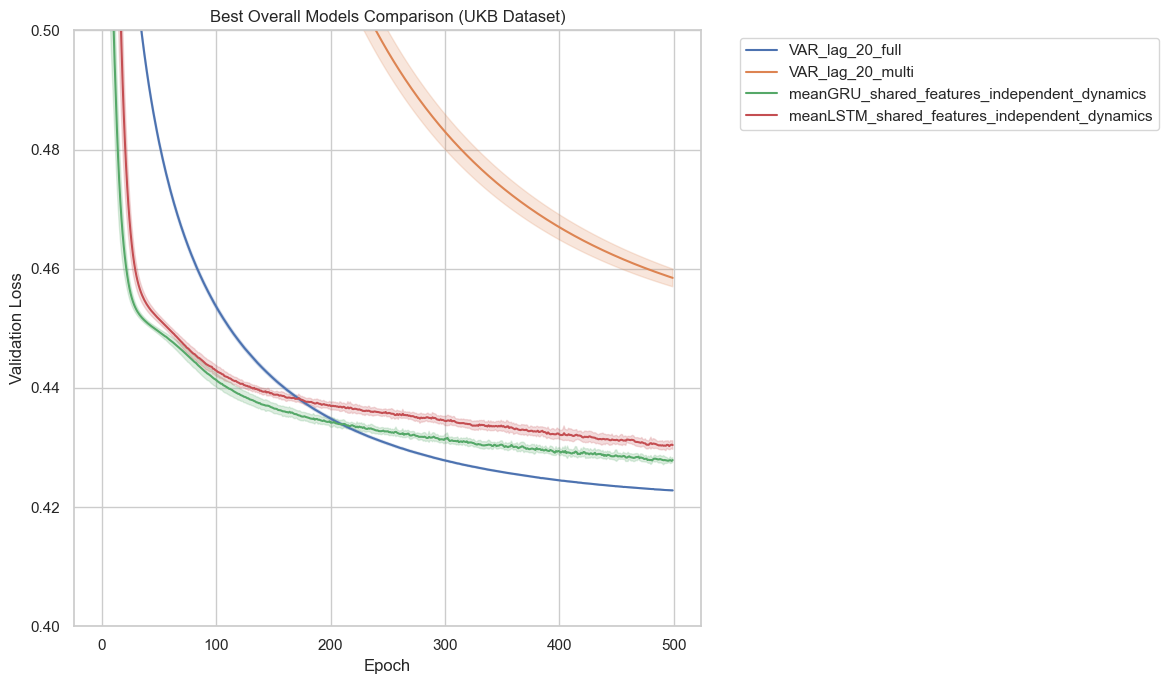

In [78]:
# Define the absolute best configs found to compare on UKB
best_configs = [
    "VAR_lag_20_full",
    "VAR_lag_20_multi",
    "meanLSTM_shared_features_independent_dynamics",
    "meanGRU_shared_features_independent_dynamics"
]

# Filter the dataset for these exact configurations
plot_df = full_df[
    (full_df["dataset"] == "ukb") & 
    (full_df["experiment"].isin(best_configs))
]

if not plot_df.empty:
    fig, ax = plt.subplots(figsize=(12, 7))
    sns.lineplot(data=plot_df, x="epoch", y="val_loss", hue="experiment", errorbar="sd")
    plt.title("Best Overall Models Comparison (UKB Dataset)")
    plt.ylabel("Validation Loss")
    plt.xlabel("Epoch")
    ax.set_ylim(0.4, 0.5)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("No exact string matches found for the best_configs array!")

### DECIFRA

meanlstm Configurations Ranked by Average Best Validation Loss on ukb_exp:


,experiment,avg_best_val_loss,std_best_val_loss,total_runs_completed
2,DECIFRA_IMix_default,0.421625,0.000871,5
3,DECIFRA_default,0.491861,0.022156,5
4,DECIFRA_noGate_default,0.494690,0.015276,5
0,DECIFRA_Gated_IMix_Res_default,0.573807,0.169035,5
1,DECIFRA_IMix_Res_default,0.763431,0.194500,4


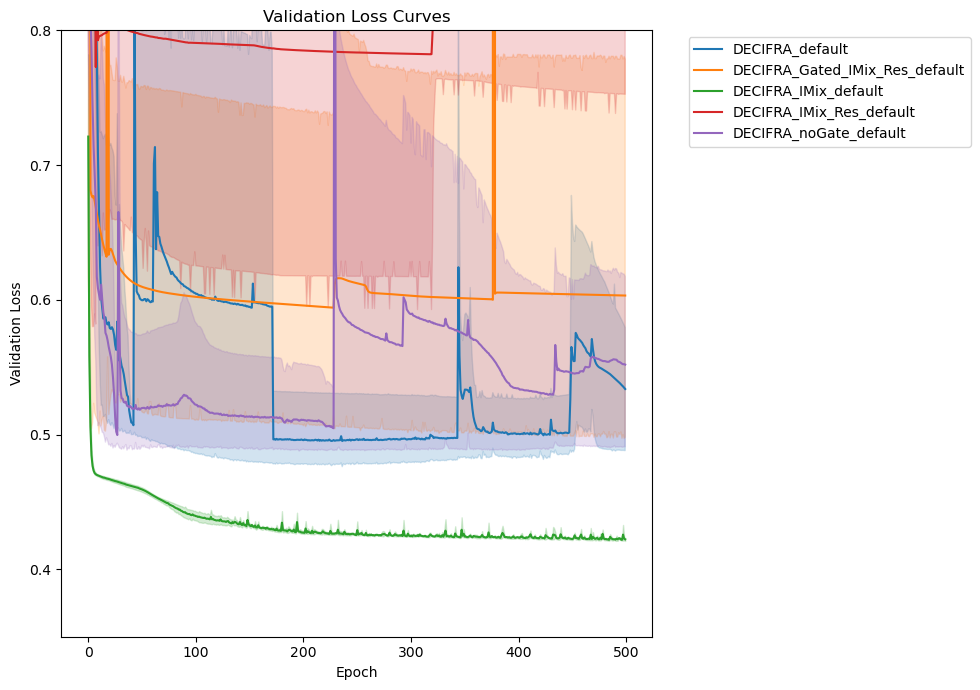

In [53]:
decifra_df = full_df[(full_df["model"].str.contains("DECIFRA")) & (full_df["dataset"] == "ukb")].copy()
# remove DECIFRA_noGate_IMix_Res, it is too scuffed
decifra_df = decifra_df[decifra_df["model"] != "DECIFRA_noGate_IMix_Res"]

def plot_df(df):
    fig, ax = plt.subplots(figsize=(10, 7))
    sns.lineplot(data=df, x="epoch", y="val_forecast_loss", hue="experiment")
    ax.set_ylim(0.35, 0.8)
    plt.title(f"Validation Loss Curves")
    plt.ylabel("Validation Loss")
    plt.xlabel("Epoch")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

# 1. Get the absolute best validation loss for EVERY independent run
best_per_run_decifra = (
    decifra_df.groupby(["experiment", "run_idx"])["val_forecast_loss"]
    .min()
    .reset_index(name="best_loss_for_run")
)

# 2. Average those best losses across all runs for a given configuration
average_best_configs_decifra = (
    best_per_run_decifra.groupby("experiment")
    .agg(
        avg_best_val_loss=("best_loss_for_run", "mean"),
        std_best_val_loss=("best_loss_for_run", "std"),
        total_runs_completed=("best_loss_for_run", "count")
    )
    .reset_index()
    .sort_values(by="avg_best_val_loss", ascending=True)
)

print("meanlstm Configurations Ranked by Average Best Validation Loss on ukb_exp:")
display(average_best_configs_decifra)

# plot the curves 

# Compare ALL meanlstm models on ukb
if not decifra_df.empty:
    plot_df(decifra_df)


# OLD Matrix Analysis
Derive and visualize internal DECIFRA attention/dynamics matrices.


In [1]:
import sys
sys.path.append("..") # Adds the DECIFRA root directory to the path

processing 00...
Instantiating DECIFRA for model_446.pt
processing 01...
Instantiating DECIFRA for model_299.pt
processing 02...
Instantiating DECIFRA for model_419.pt
processing 03...
Instantiating DECIFRA for model_54.pt
processing 04...


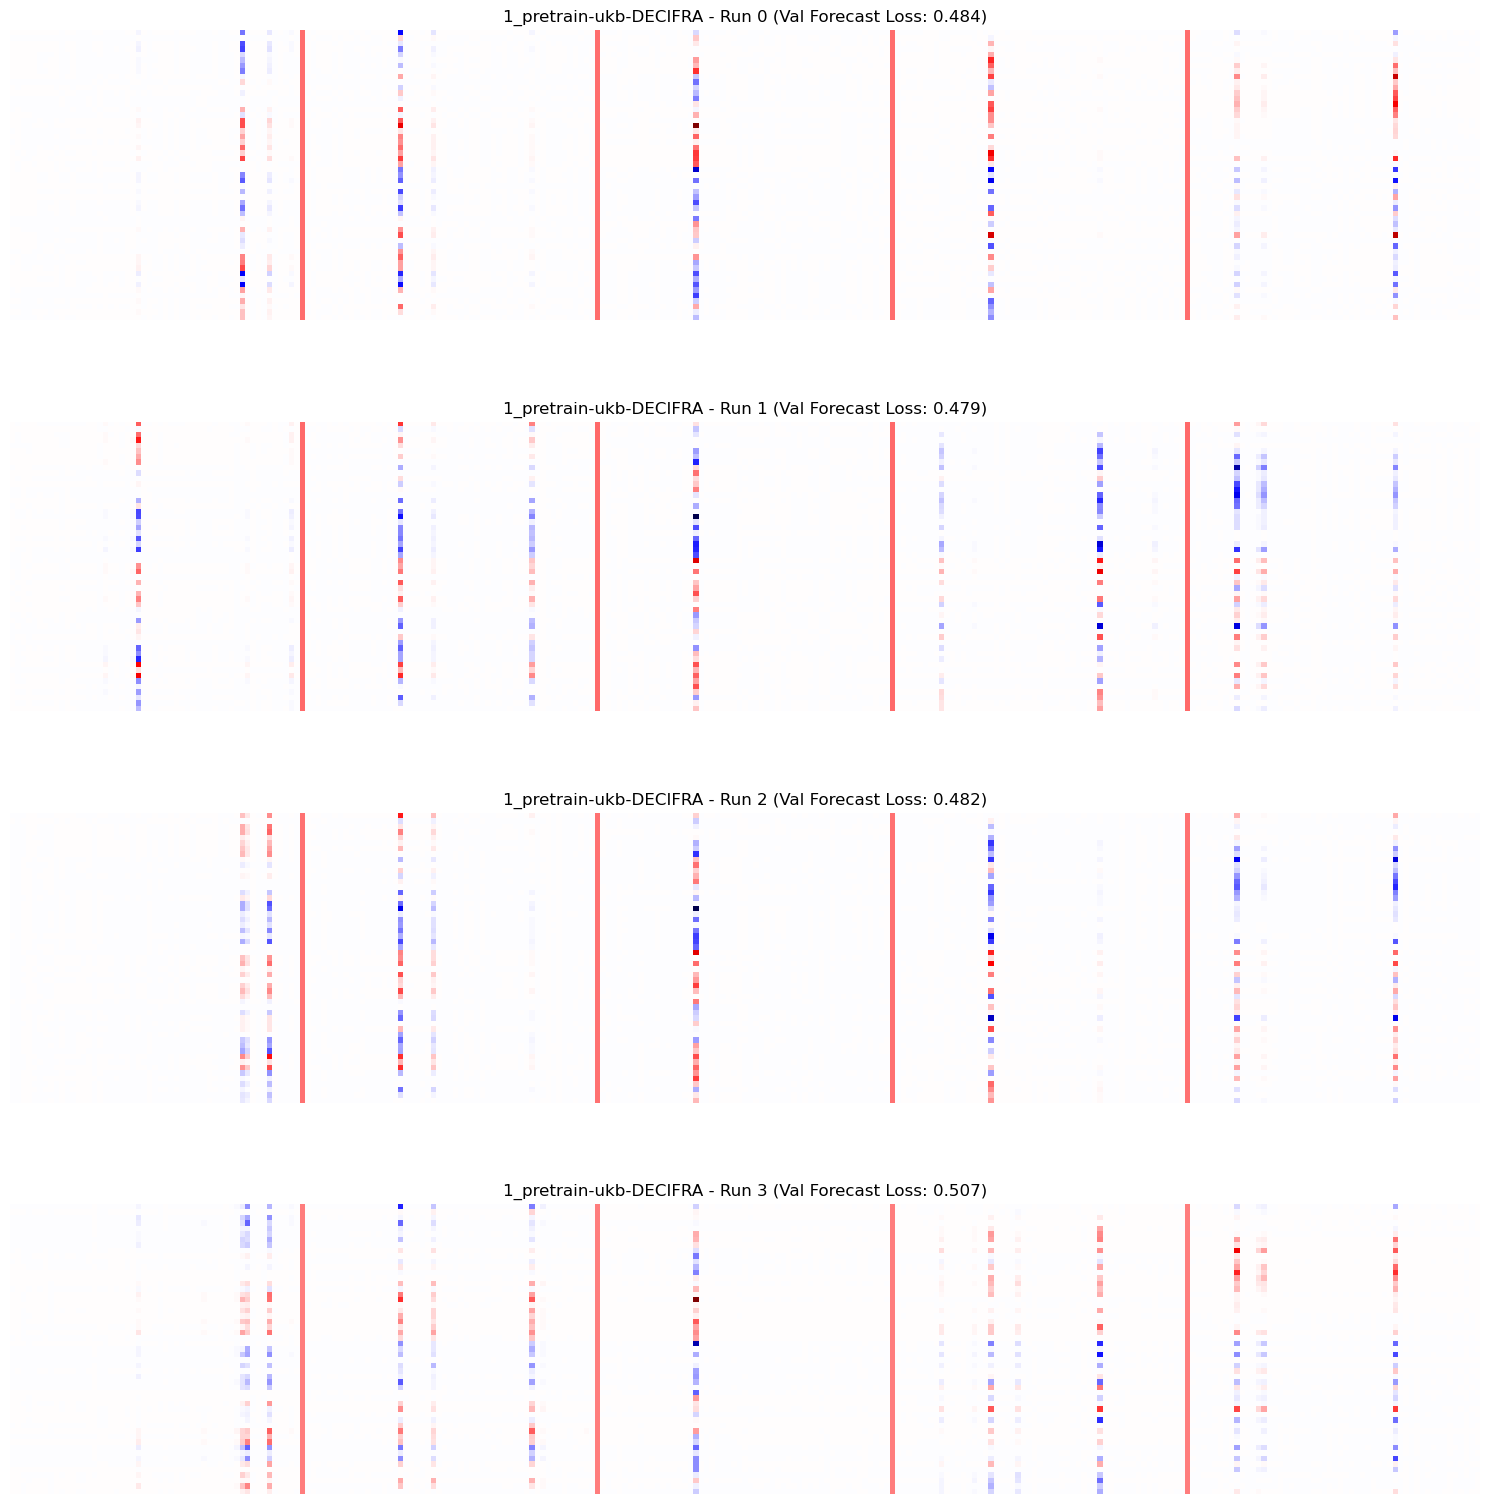

processing 00...
Instantiating DECIFRA_Gated_IMix_Res for model_3.pt
processing 01...
Instantiating DECIFRA_Gated_IMix_Res for model_18.pt
processing 02...
Instantiating DECIFRA_Gated_IMix_Res for model_499.pt
processing 03...
Instantiating DECIFRA_Gated_IMix_Res for model_499.pt
processing 04...
Instantiating DECIFRA_Gated_IMix_Res for model_376.pt


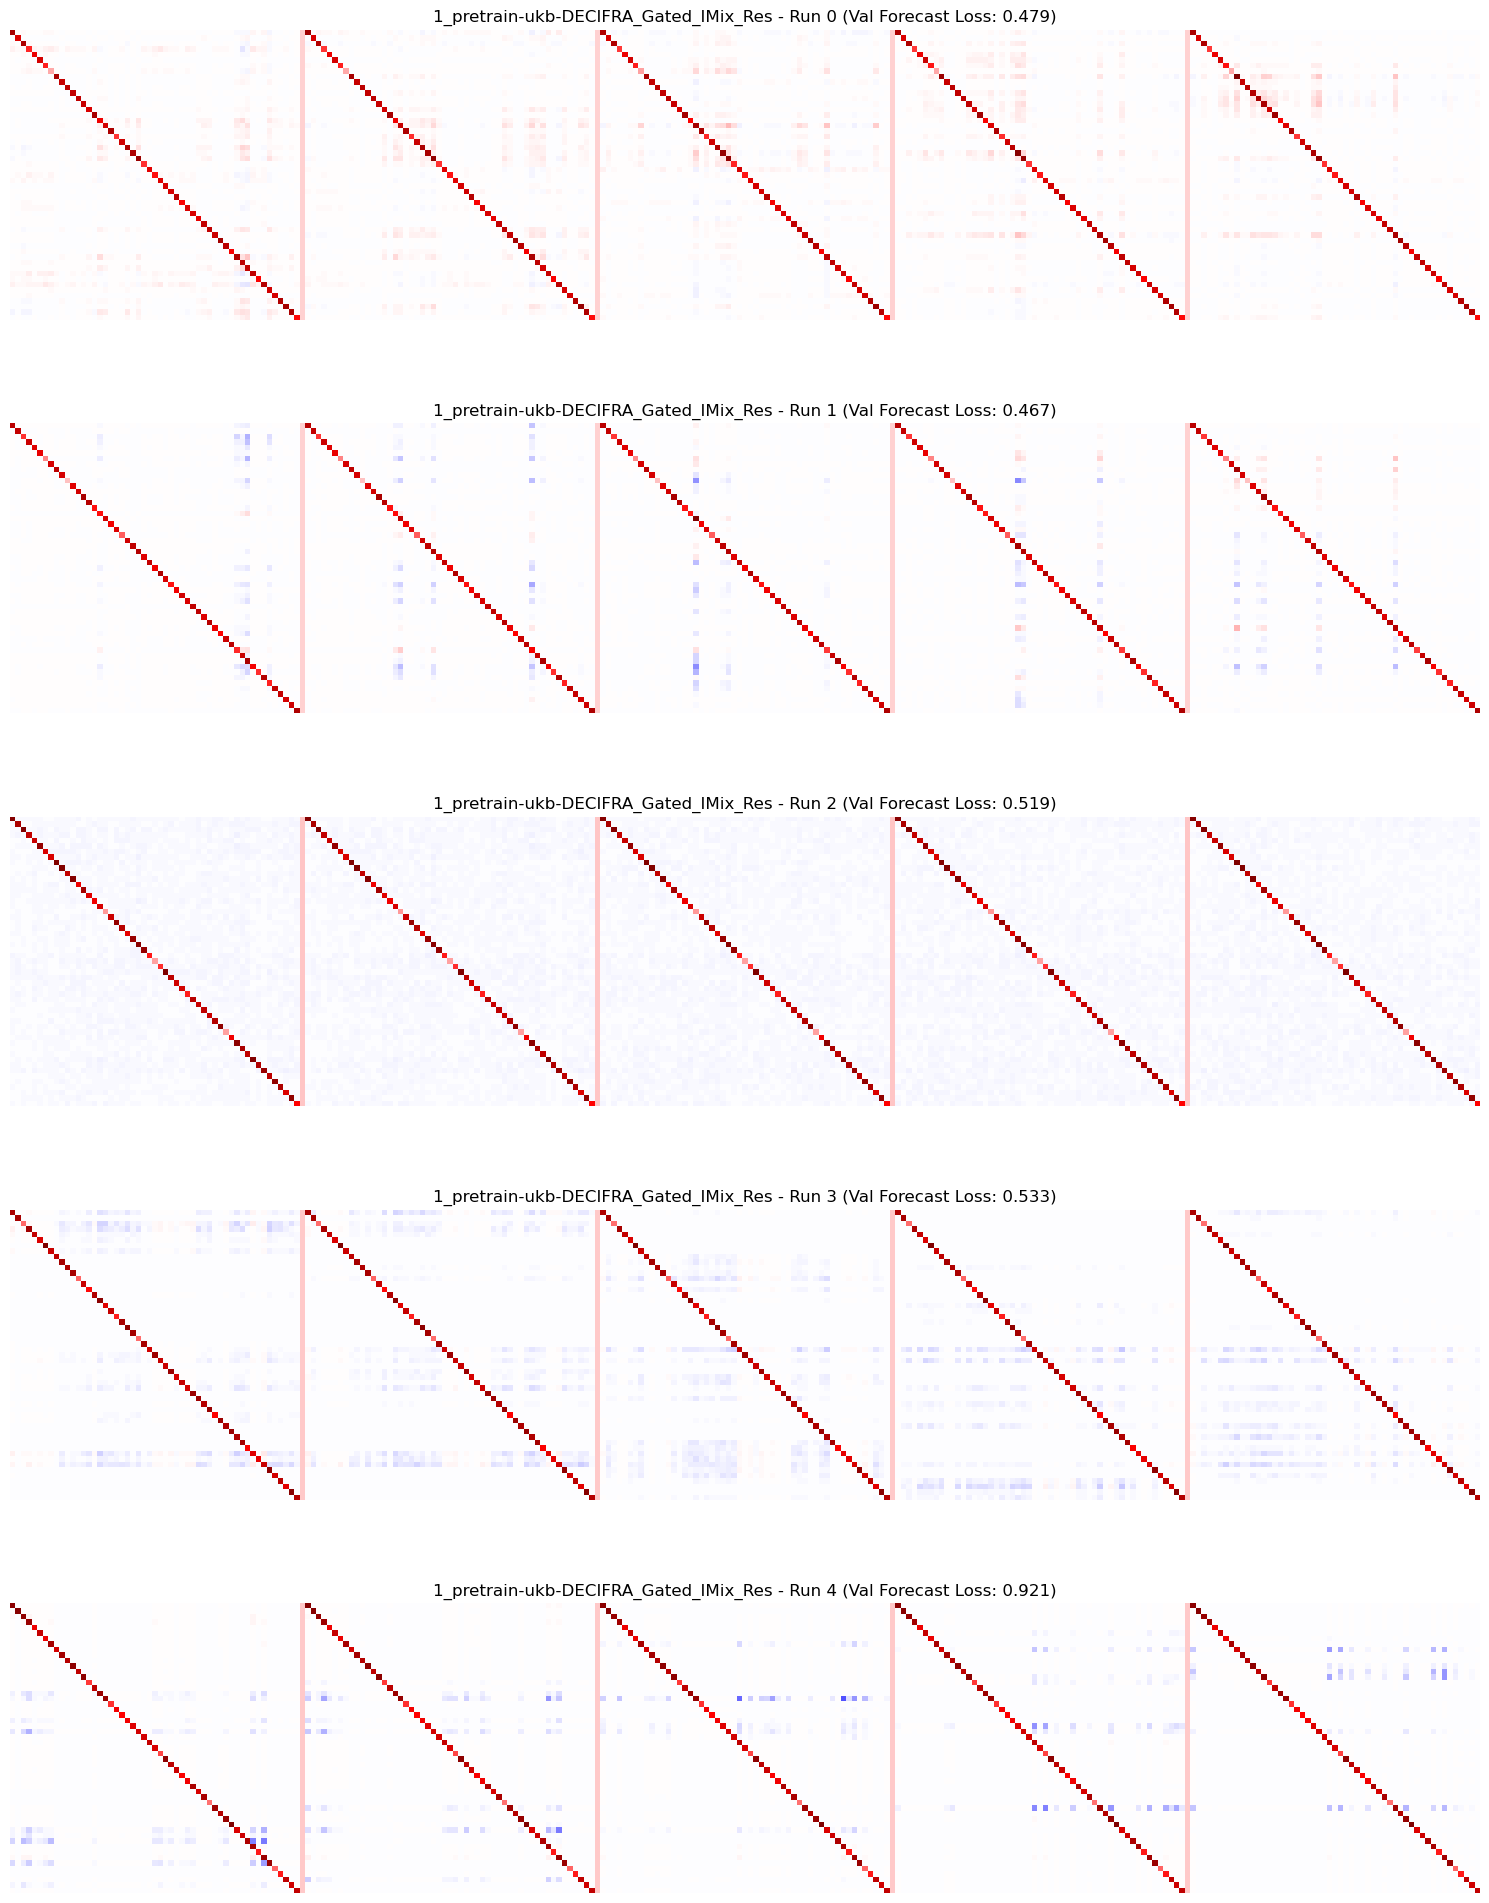

In [55]:
analyze_model_in("/Users/ppopov1/DECIFRA/assets/logs/1_pretrain-ukb-DECIFRA")
analyze_model_in("/Users/ppopov1/DECIFRA/assets/logs/1_pretrain-ukb-DECIFRA_Gated_IMix_Res")

# Modular Matrix Analysis
Cached derivation and aggregated visualization grid logic.


In [57]:
import torch
import os
import sys
sys.path.append("..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from omegaconf import OmegaConf
from src.datasets.fbirn import load_data as load_fbirn
import src.models.DECIFRA as DECIFRA_module

# 1. Load FBIRN once for matrix derivation
FBIRN_DATADICT, _ = load_fbirn()
FBIRN_DATA = FBIRN_DATADICT['data']

def derive_matrices_generalized(model_cfg, ckpt_path, model_class_override=None):
    """Generalized derivation that detects model class from config or state_dict."""
    device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
    ckpt = torch.load(ckpt_path, map_location='cpu')
    state_dict = ckpt.get('state_dict', ckpt)
    
    # Class detection logic
    model_class_name = model_cfg.get("model_class", model_class_override)
    if model_class_name is None:
        if "BTP.res_weight" in state_dict:
             model_class_name = "DECIFRA_Gated_IMix_Res" if "BTP.gate.bias" in state_dict else "DECIFRA_noGate_IMix_Res"
        else:
             model_class_name = "DECIFRA"
             
    model_class = getattr(DECIFRA_module, model_class_name, DECIFRA_module.DECIFRA)
    model = model_class(model_cfg)
    model.load_state_dict(state_dict)
    model = model.to(device).eval()

    with torch.no_grad():
        _, output = model(torch.tensor(FBIRN_DATA, dtype=torch.float32).to(device))
    return output["matrices"].detach().cpu().numpy()

def get_model_results(subrun_path, use_cache=True):
    """Loads matrices (from cache if available), loss, and best epoch for a subrun."""
    cache_path = os.path.join(subrun_path, "fbirn_matrices.npy")
    best_txt = os.path.join(subrun_path, "best_epoch.txt")
    cfg_path = os.path.join(subrun_path, "model_config.yaml")
    logs_path = os.path.join(subrun_path, "train_logs.csv")
    
    if not (os.path.exists(best_txt) and os.path.exists(cfg_path)):
        return None, None, None

    # Load/Derive Matrices
    if use_cache and os.path.exists(cache_path):
        matrices = np.load(cache_path)
    else:
        best_idx = int(open(best_txt).read().strip())
        ckpt = os.path.join(subrun_path, f"checkpoints/model_{best_idx}.pt")
        matrices = derive_matrices_generalized(OmegaConf.load(cfg_path), ckpt)
        np.save(cache_path, matrices)

    # Extract Loss
    loss = None
    best_epoch = int(open(best_txt).read().strip())
    if os.path.exists(logs_path):
        try:
            df = pd.read_csv(logs_path)
            row = df[df['epoch'] == best_epoch]
            if not row.empty: loss = row['val_forecast_loss'].values[0]
        except:
            pass
            
    return matrices, loss, best_epoch

def plot_aggregated_matrices(matrices_list, titles_list, save_path, n_samples=1):
    """Modular plotting engine for comparison grids."""
    n_runs = len(matrices_list)
    fig, axes = plt.subplots(n_runs, 1, figsize=(15, 3.8 * n_runs))
    if n_runs == 1: axes = [axes]
    
    for idx, matrices in enumerate(matrices_list):
        abs_max = np.max(np.abs(matrices[:n_samples, 50:55]))
        vlim = abs_max if abs_max > 0 else 0.1
        ms = matrices.shape[2]
        combined = np.full(((ms + 1)*n_samples - 1, (ms + 1)*5 - 1), 0.1)
        for i in range(n_samples):
            for j in range(5):
                combined[i*(ms+1):i*(ms+1)+ms, j*(ms+1):j*(ms+1)+ms] = matrices[i, 50+j]
        
        axes[idx].imshow(combined, cmap='seismic', vmin=-vlim, vmax=vlim, interpolation='none')
        axes[idx].set_title(titles_list[idx], fontsize=12)
        axes[idx].axis('off')
        
    plt.tight_layout()
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, dpi=300)
    plt.show()

def analyze_model_in(model_exp_path):
    """High-level entry point to analyze all initializations in an experiment folder."""
    all_m, all_t = [], []
    for sub in sorted(os.listdir(model_exp_path)):
        sub_path = os.path.join(model_exp_path, sub)
        if not os.path.isdir(sub_path): continue
        m, l, _ = get_model_results(sub_path)
        if m is not None:
            all_m.append(m)
            all_t.append(f"{os.path.basename(model_exp_path)}/{sub} | Loss: {l:.03f}" if l is not None else f"{sub}")
            
    if all_m: plot_aggregated_matrices(all_m, all_t, f"assets/plots/matrices_{os.path.basename(model_exp_path)}.png")


## Comparisons


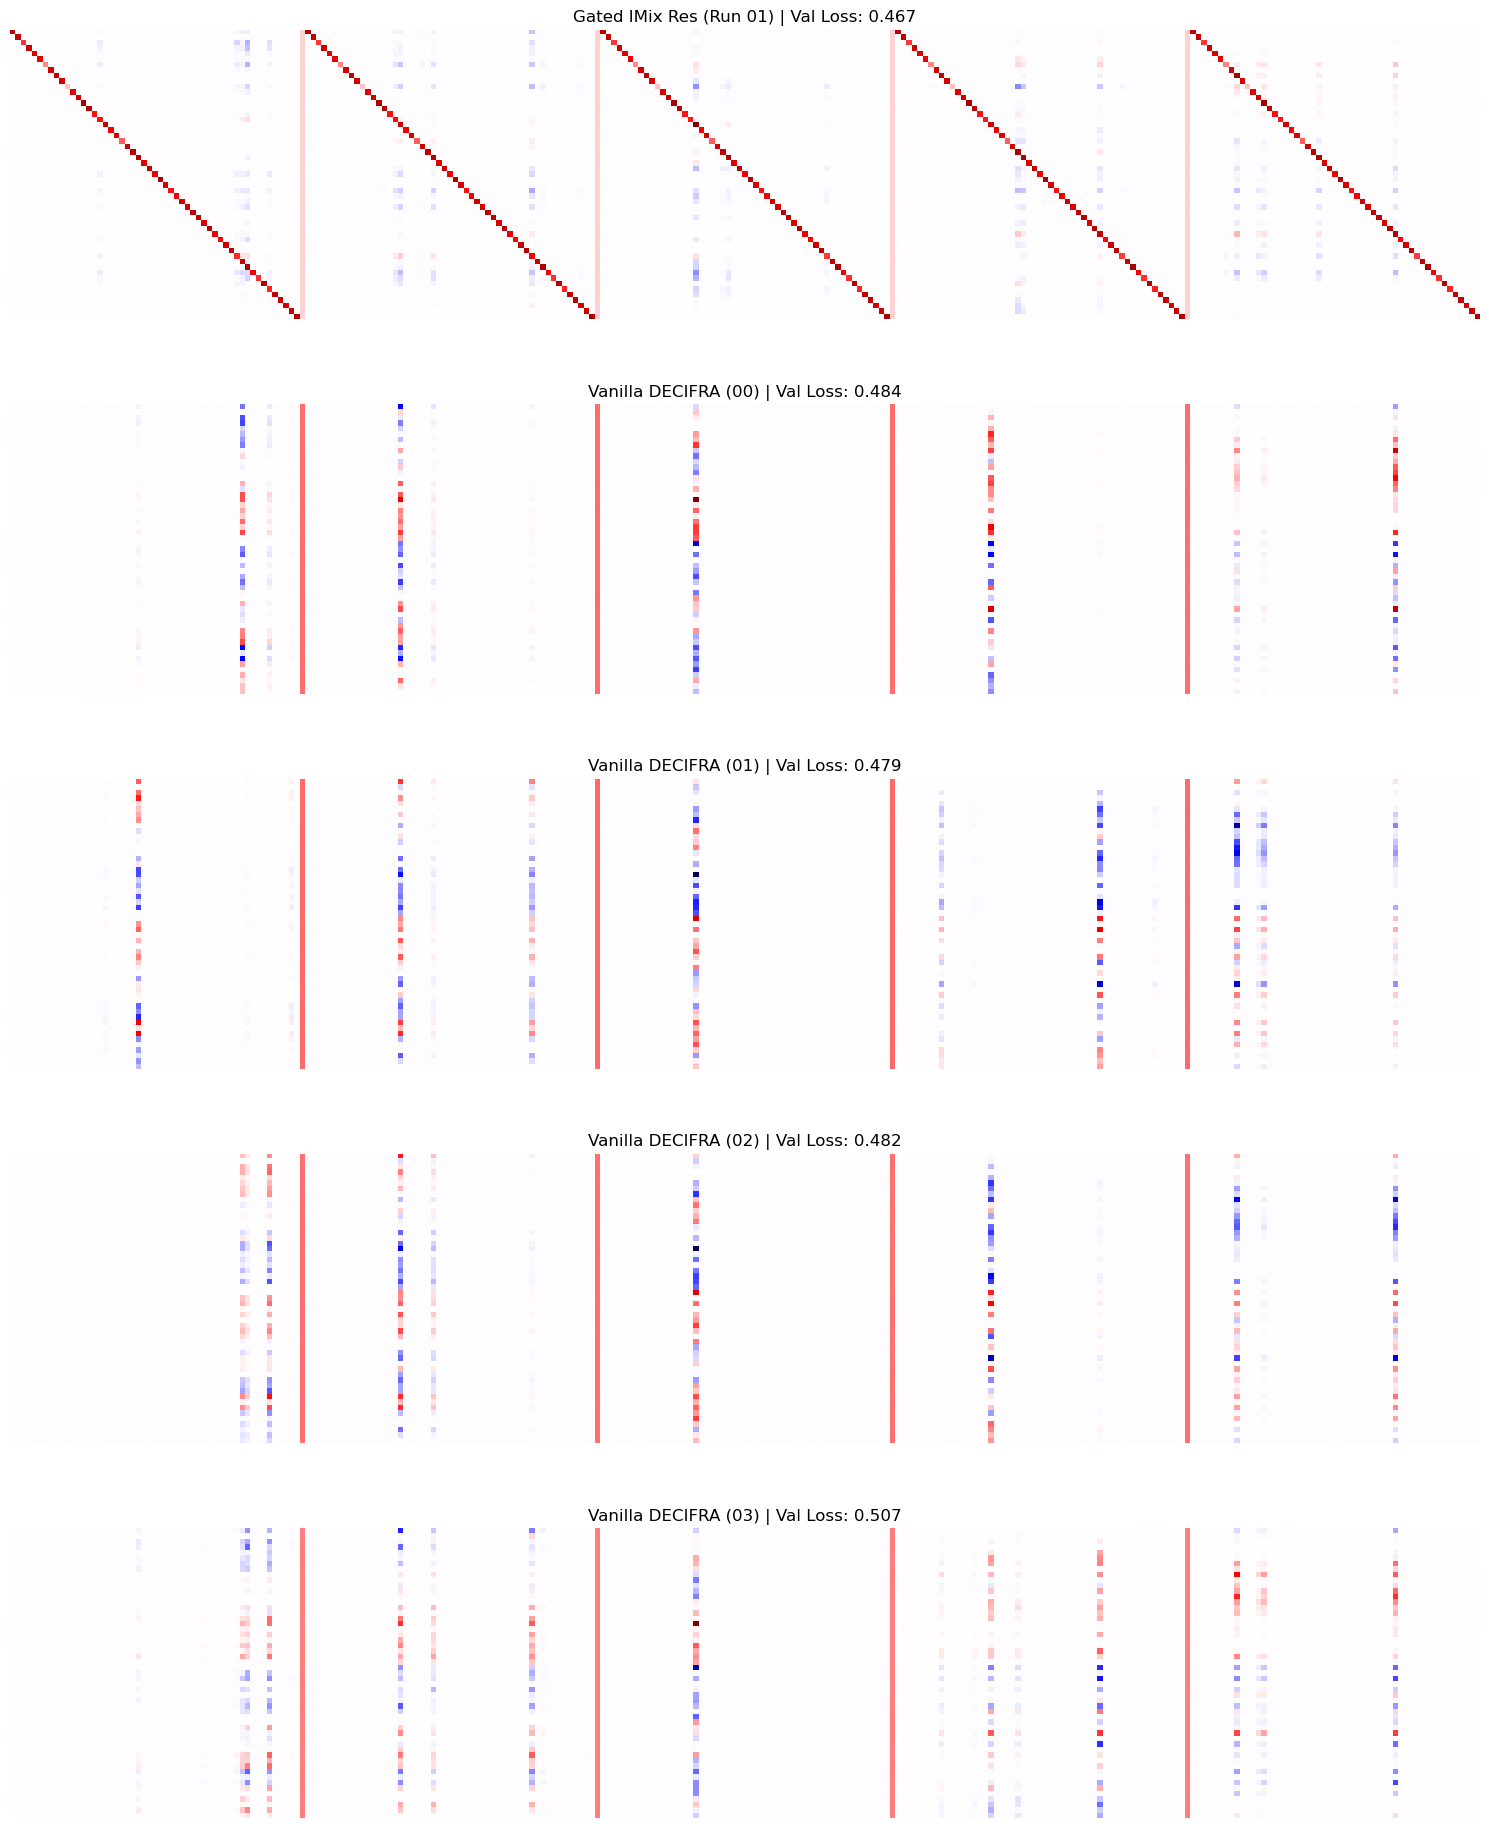

In [58]:
# Comparison: Gated Run 01 vs All Vanilla Runs
gated_path = "/Users/ppopov1/DECIFRA/assets/logs/1_pretrain-ukb-DECIFRA_Gated_IMix_Res/01"
vanilla_base = "/Users/ppopov1/DECIFRA/assets/logs/1_pretrain-ukb-DECIFRA"

comp_m, comp_t = [], []

# 1. Load Gated Run 01
m, l, _ = get_model_results(gated_path)
if m is not None:
    comp_m.append(m)
    comp_t.append(f"Gated IMix Res (Run 01) | Val Loss: {l:.03f}")

# 2. Load All Vanilla Runs
if os.path.exists(vanilla_base):
    for sub in sorted(os.listdir(vanilla_base)):
        sub_path = os.path.join(vanilla_base, sub)
        if not os.path.isdir(sub_path): continue
        m, l, _ = get_model_results(sub_path)
        if m is not None:
            comp_m.append(m)
            comp_t.append(f"Vanilla DECIFRA ({sub}) | Val Loss: {l:.03f}" if l is not None else f"Vanilla ({sub})")

if comp_m:
    plot_aggregated_matrices(comp_m, comp_t, "assets/plots/comparison_gated_vs_vanilla.png")
